## Exploratory Data Analysis

### Synthetic Supplier and Commodity Dataset (Raw)

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.2f}".format)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name != "Final-Year-Project-2025":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "syn_supplier_commodity_dataset.csv"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "preprocessed_data.csv"

raw_df = pd.read_csv(RAW_DATA_PATH)
processed_df = pd.read_csv(PROCESSED_DATA_PATH)
print(f"Raw data shape: {raw_df.shape} | Processed data shape: {processed_df.shape}")
raw_df.head()

Raw data shape: (10200, 30) | Processed data shape: (10200, 30)


,Supplier_ID,Commodity_ID,Supplier_Name,Commodity_Name,Country,Region,Supplier_Tier,Industry_Sector,ESG_Score,Environmental_Score,Social_Score,Governance_Score,Carbon_Emission_Intensity,Water_Intensity,Waste_Management_Efficiency,Renewable_Energy_Usage,Compliance_Level,Sustainability_Report_Availability,Lead_Time_Days,Production_Capacity,On_Time_Delivery_Rate,Defect_Rate,Financial_Stability_Score,Cost_Index,Labour_Compliance_Score,Diversity_Index,Supplier_Audit_Score,Incident_History_Count,Logistics_Distance_km,Risk_Classification
0,S0001446,C0001446,Foxconn,Printed Circuit Boards,India,Asia-Pacific,2,Electronics,73.76,70.82,64.13,86.33,0.15,1332.53,0.79,0.19,3.00,1.00,39.00,17365.00,0.90,0.00,NaN,1.14,87.70,0.86,70.83,0.00,10919.00,Low
1,S0006606,C0006606,Foxconn,Electronic Components,Indonesia,Asia-Pacific,1,Electronics,71.39,54.41,78.77,81.00,0.88,NaN,0.82,0.55,3.00,0.00,21.00,22855.00,0.82,0.05,53.09,0.84,85.82,0.82,74.10,2.00,4463.00,Moderate
2,S0001738,C0001738,Samsung Electronics,LCD Panels,Indonesia,Asia-Pacific,3,Electronics,51.66,40.46,54.84,59.69,0.21,536.47,0.52,0.50,2.00,1.00,8.00,7147.00,0.87,0.03,100.00,1.43,78.42,0.33,73.13,0.00,969.00,Moderate
3,S0001722,C0001722,Olam International,Cocoa,USA,North America,2,Agriculture,74.22,58.91,77.85,85.89,0.65,1199.69,0.43,0.77,3.00,0.00,42.00,42110.00,0.85,0.03,84.14,1.30,83.58,0.57,65.20,1.00,10116.00,Low
4,S0009998,C0009998,Bunge Limited,Canola,China,Asia-Pacific,3,Agriculture,44.33,31.66,65.53,35.80,0.48,519.54,0.46,0.12,1.00,1.00,13.00,18740.00,0.91,0.04,59.96,0.95,70.84,0.38,68.54,1.00,4508.00,Moderate


In [2]:
# Dataset overview
print("=== Raw DataFrame Info ===")
raw_df.info()

print("\n=== Processed DataFrame Info ===")
processed_df.info()

summary_table = pd.DataFrame({
    "dtype": raw_df.dtypes,
    "missing": raw_df.isna().sum(),
    "missing_%": (raw_df.isna().mean() * 100).round(2),
    "unique": raw_df.nunique(),
})
summary_table.sort_values("missing", ascending=False).head(10)


=== Raw DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10200 entries, 0 to 10199
Data columns (total 30 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Supplier_ID                         10200 non-null  object 
 1   Commodity_ID                        10200 non-null  object 
 2   Supplier_Name                       10200 non-null  object 
 3   Commodity_Name                      10200 non-null  object 
 4   Country                             10200 non-null  object 
 5   Region                              10200 non-null  object 
 6   Supplier_Tier                       10200 non-null  int64  
 7   Industry_Sector                     10200 non-null  object 
 8   ESG_Score                           9994 non-null   float64
 9   Environmental_Score                 9996 non-null   float64
 10  Social_Score                        9997 non-null   float64
 11  Governance_Sco

,dtype,missing,missing_%,unique
Water_Intensity,float64,207,2.03,9485
Governance_Score,float64,206,2.02,4828
ESG_Score,float64,206,2.02,3553
Renewable_Energy_Usage,float64,205,2.01,101
Sustainability_Report_Availability,float64,205,2.01,2
Incident_History_Count,float64,204,2.00,8
Waste_Management_Efficiency,float64,204,2.00,91
Cost_Index,float64,204,2.00,211
Environmental_Score,float64,204,2.00,5088
Production_Capacity,float64,203,1.99,8876


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11


In [4]:
# Missing values analysis
missing_counts = raw_df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(raw_df) * 100).round(2)
missing_summary = pd.DataFrame({"Missing Count": missing_counts, "% Missing": missing_pct})
missing_summary[missing_summary["Missing Count"] > 0]

,Missing Count,% Missing
Water_Intensity,207,2.03
Governance_Score,206,2.02
ESG_Score,206,2.02
Renewable_Energy_Usage,205,2.01
Sustainability_Report_Availability,205,2.01
Incident_History_Count,204,2.00
Waste_Management_Efficiency,204,2.00
Cost_Index,204,2.00
Environmental_Score,204,2.00
Production_Capacity,203,1.99


C:\Users\amtan\AppData\Local\Temp\ipykernel_25188\2674726484.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


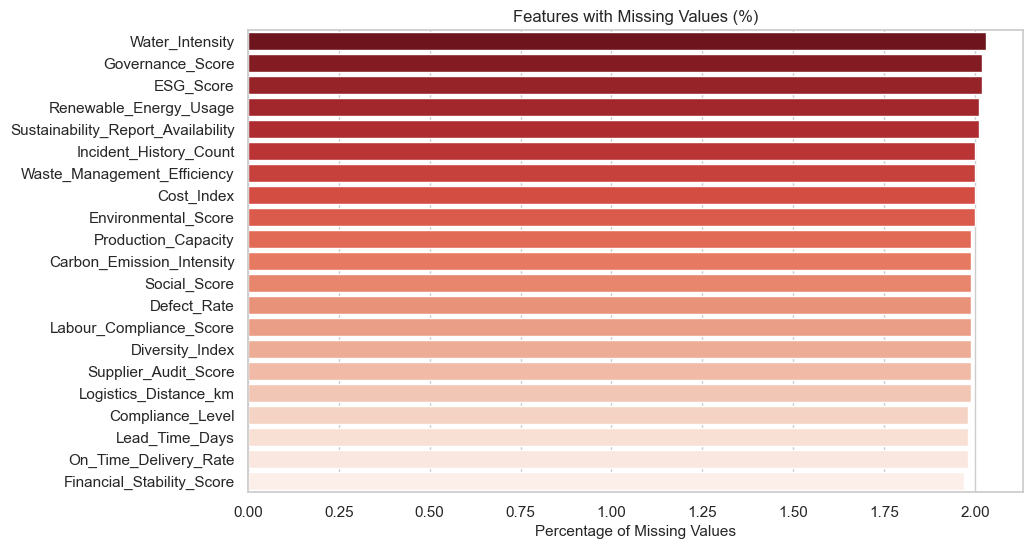

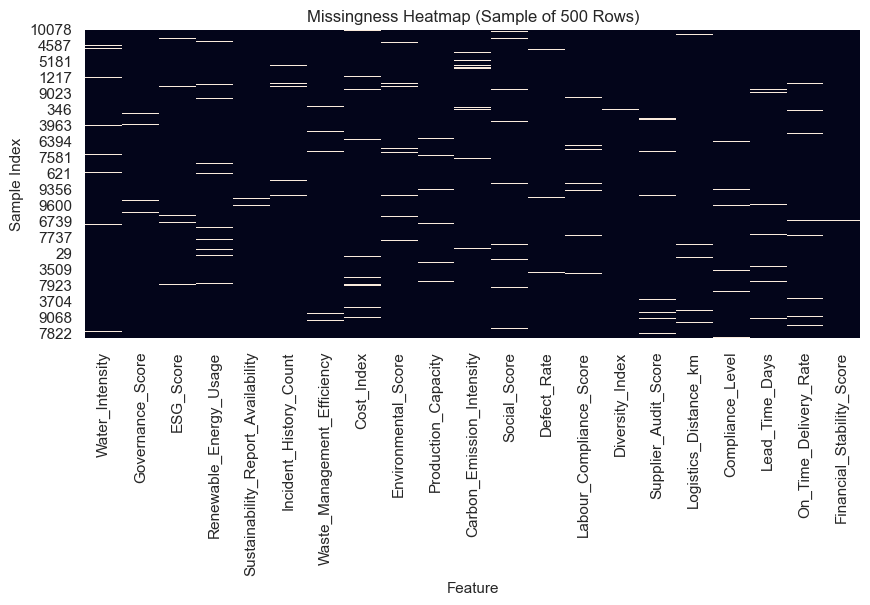

In [5]:
# Visualize missingness pattern
nonzero_missing = missing_summary[missing_summary["Missing Count"] > 0]
if not nonzero_missing.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=nonzero_missing.reset_index().rename(columns={"index": "Feature"}),
        y="Feature",
        x="% Missing",
        palette="Reds_r",
    )
    plt.title("Features with Missing Values (%)")
    plt.xlabel("Percentage of Missing Values")
    plt.ylabel("")
    plt.show()

    sample = raw_df[nonzero_missing.index].sample(n=500, random_state=42)
    plt.figure(figsize=(10, 4))
    sns.heatmap(sample.isna(), cbar=False)
    plt.title("Missingness Heatmap (Sample of 500 Rows)")
    plt.xlabel("Feature")
    plt.ylabel("Sample Index")
    plt.show()
else:
    print("No missing data detected in the raw dataset.")


In [6]:
# Top categorical breakdowns
categorical_features = ["Region", "Country", "Industry_Sector", "Supplier_Name", "Risk_Classification"]
cat_summary = {}
for feature in categorical_features:
    top_values = raw_df[feature].value_counts().head(5)
    cat_summary[feature] = top_values
cat_summary

{'Region': Region
 Asia-Pacific     7245
 South America    1523
 North America    1432
 Name: count, dtype: int64,
 'Country': Country
 Brazil      1519
 India       1504
 Malaysia    1472
 China       1467
 USA         1429
 Name: count, dtype: int64,
 'Industry_Sector': Industry_Sector
 Agriculture        6179
 Electronics        1600
 Chemicals          1123
 Metals              797
 Food & Beverage     501
 Name: count, dtype: int64,
 'Supplier_Name': Supplier_Name
 Sime Darby Plantation     825
 Foxconn                   822
 Olam International        805
 Archer Daniels Midland    801
 Tata Steel                796
 Name: count, dtype: int64,
 'Risk_Classification': Risk_Classification
 Moderate    7097
 Low         2972
 High         131
 Name: count, dtype: int64}

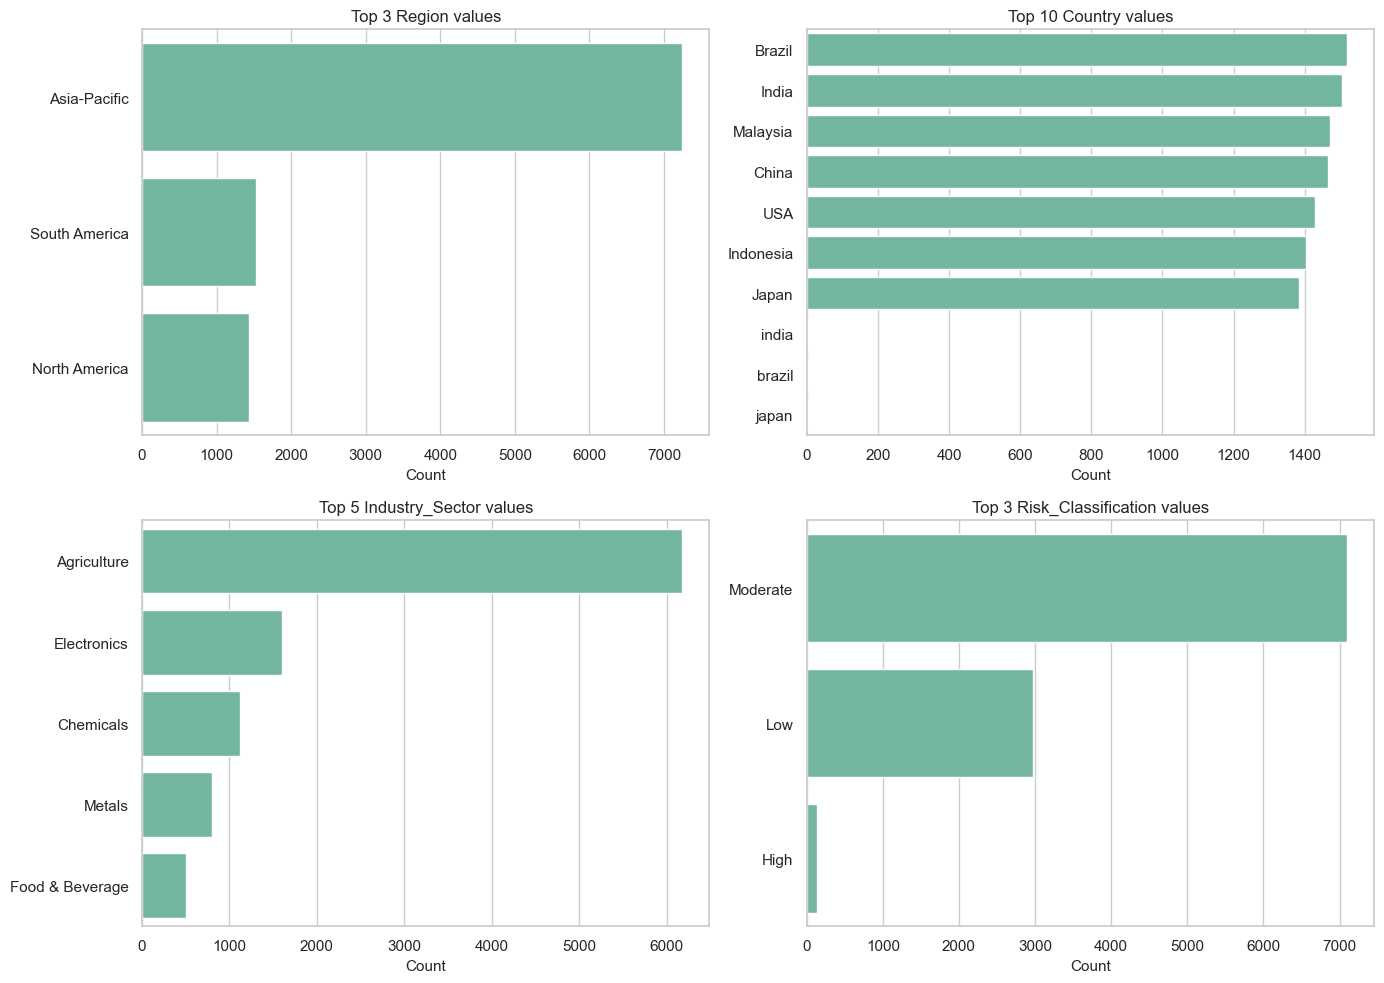

In [7]:
# Visualize categorical distributions
plot_features = ["Region", "Country", "Industry_Sector", "Risk_Classification"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for feature, ax in zip(plot_features, axes):
    counts = raw_df[feature].value_counts().head(10)
    sns.barplot(x=counts.values, y=counts.index, ax=ax)
    ax.set_title(f"Top {min(10, len(counts))} {feature} values")
    ax.set_xlabel("Count")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

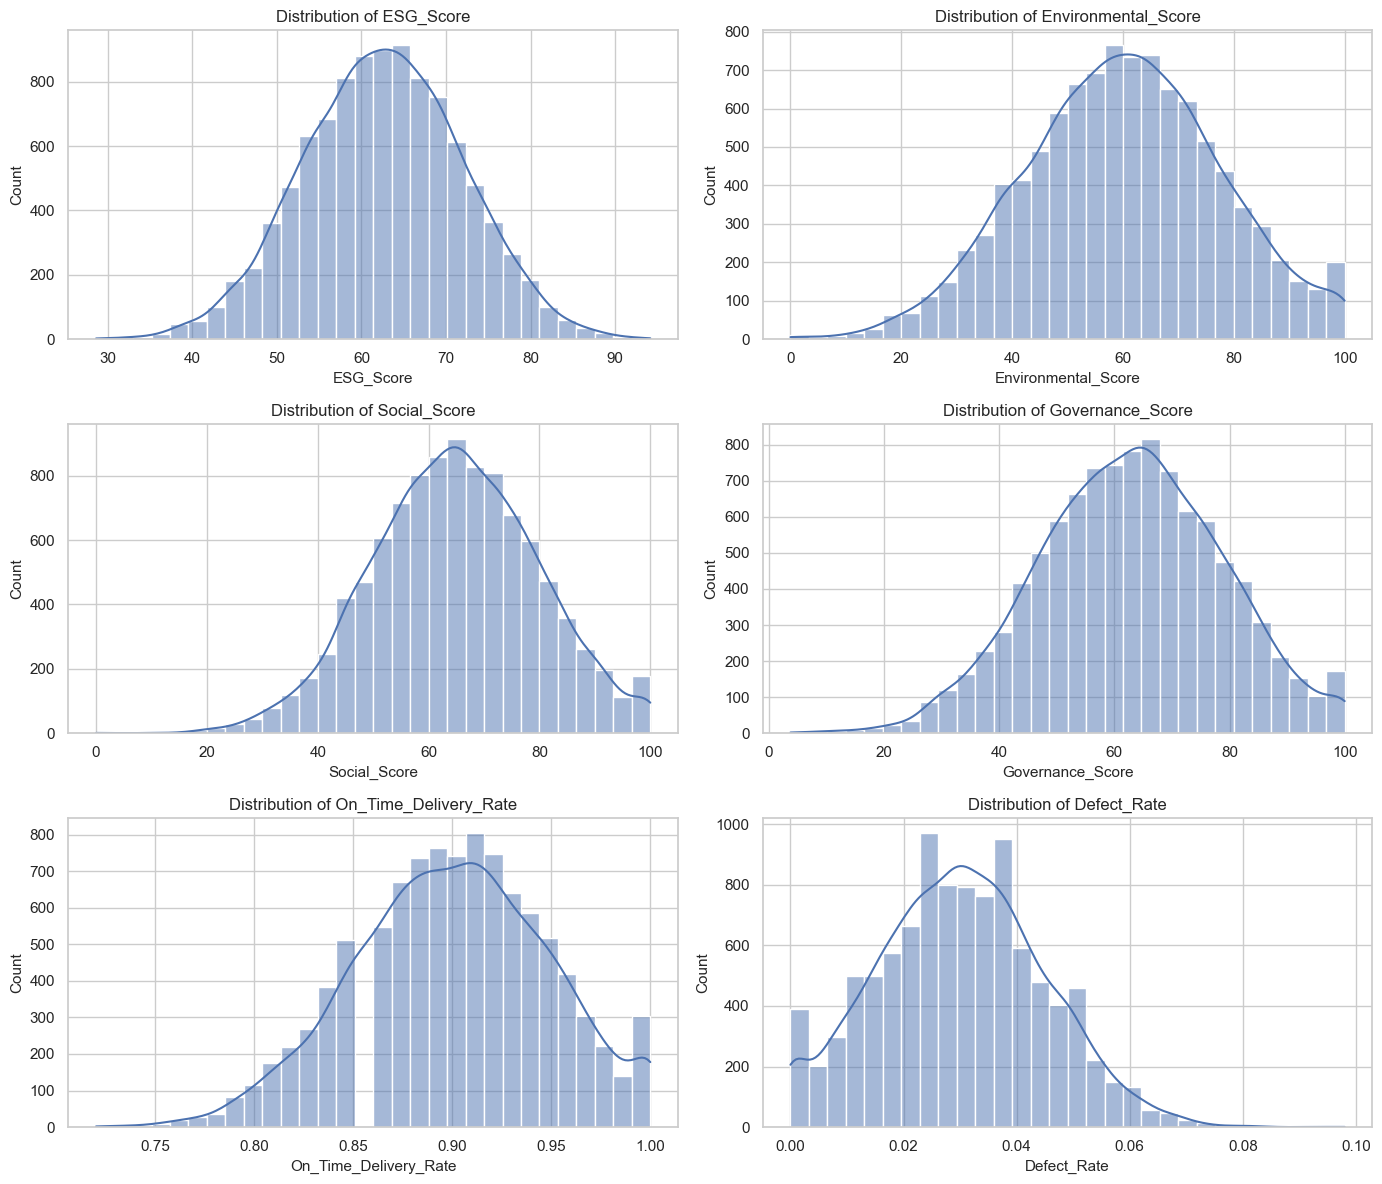

In [8]:
# Numeric feature distributions
numeric_features = [
    "ESG_Score",
    "Environmental_Score",
    "Social_Score",
    "Governance_Score",
    "On_Time_Delivery_Rate",
    "Defect_Rate",
]
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for feature, ax in zip(numeric_features, axes):
    sns.histplot(raw_df[feature], kde=True, bins=30, ax=ax, color="#4C72B0")
    ax.set_title(f"Distribution of {feature}")

plt.tight_layout()
plt.show()



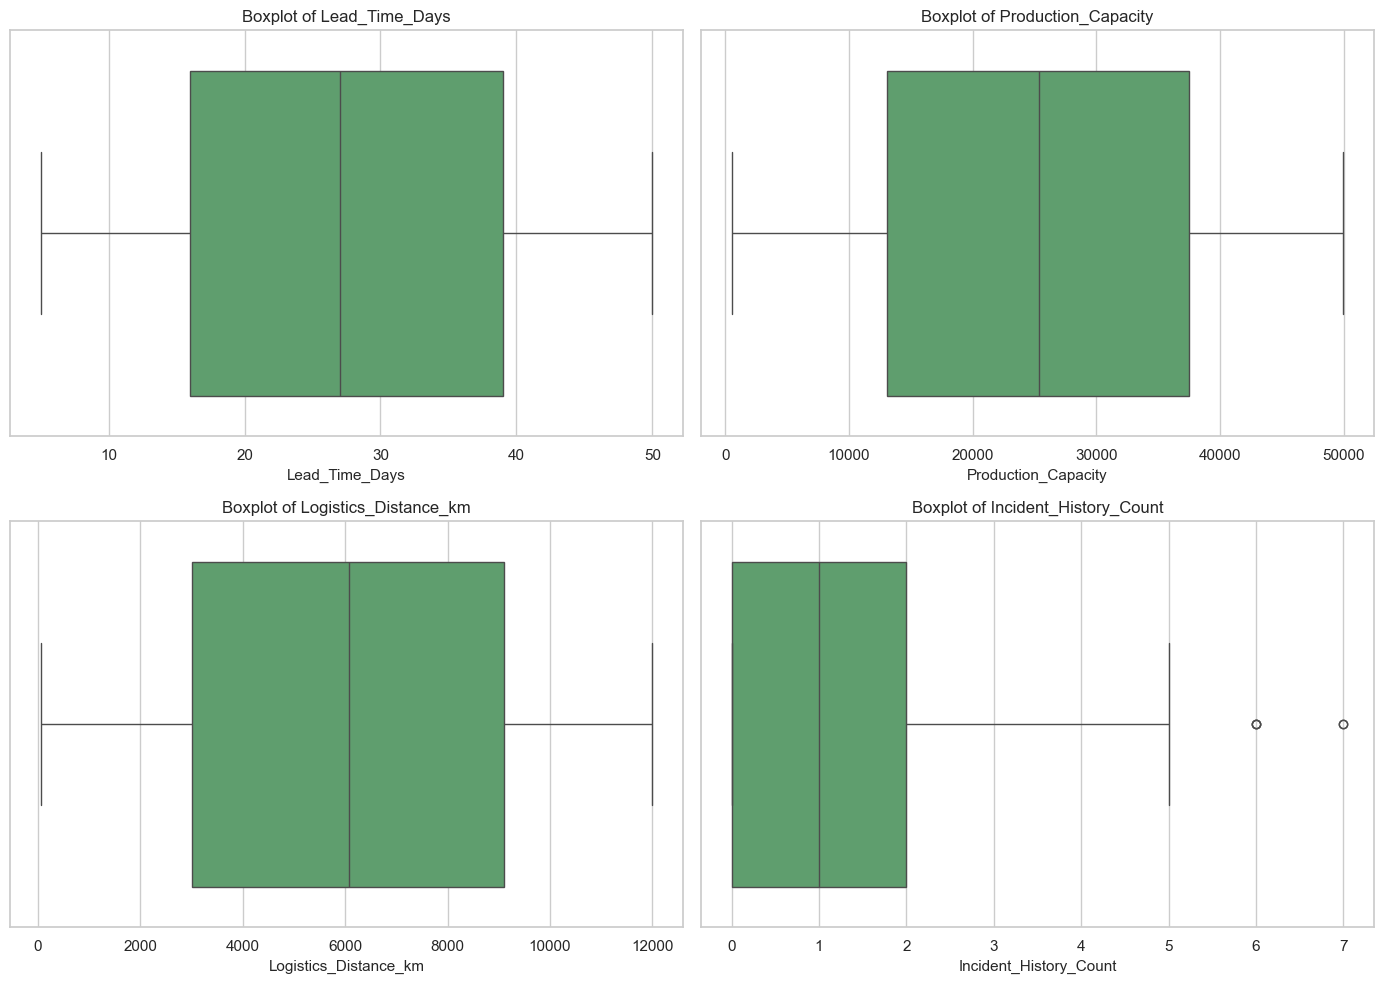

In [9]:
# Boxplots to inspect outliers
boxplot_features = [
    "Lead_Time_Days",
    "Production_Capacity",
    "Logistics_Distance_km",
    "Incident_History_Count",
]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for feature, ax in zip(boxplot_features, axes):
    sns.boxplot(x=raw_df[feature], ax=ax, color="#55A868")
    ax.set_title(f"Boxplot of {feature}")

plt.tight_layout()
plt.show()



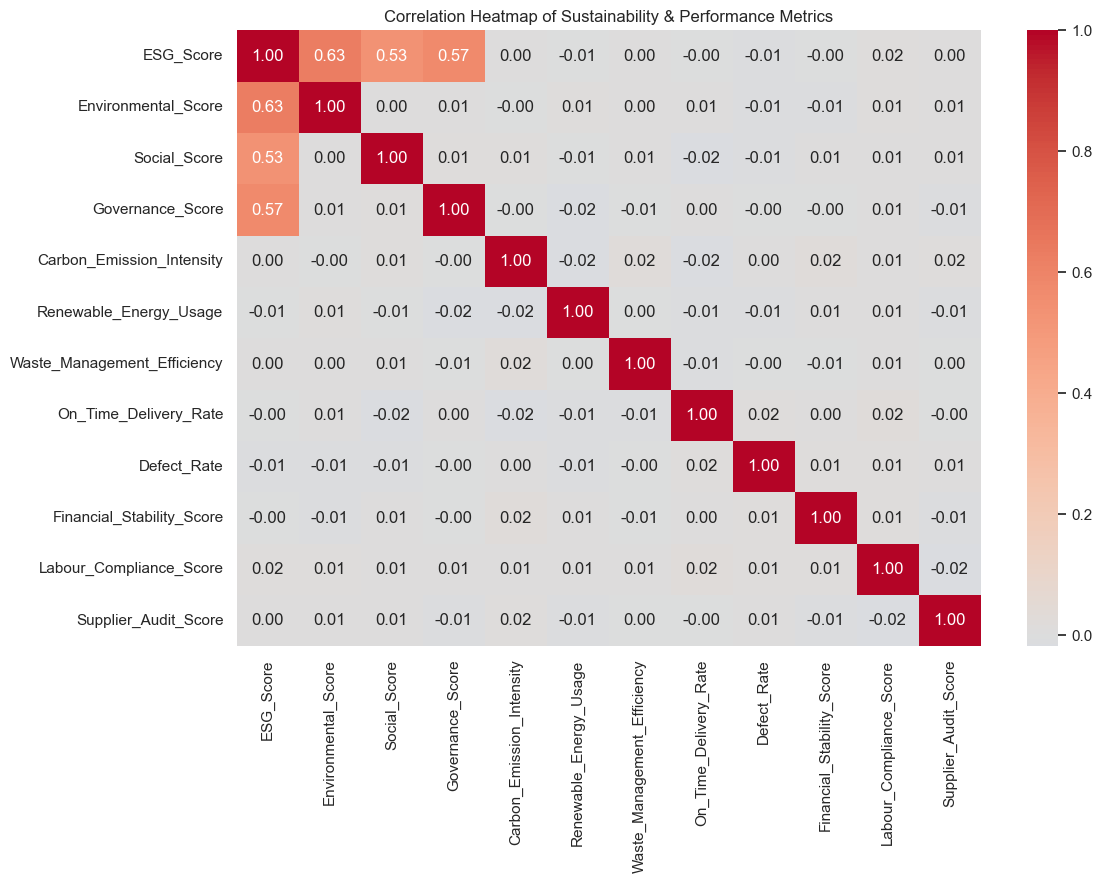

In [10]:
# Correlation heatmap for key numeric metrics
corr_features = [
    "ESG_Score",
    "Environmental_Score",
    "Social_Score",
    "Governance_Score",
    "Carbon_Emission_Intensity",
    "Renewable_Energy_Usage",
    "Waste_Management_Efficiency",
    "On_Time_Delivery_Rate",
    "Defect_Rate",
    "Financial_Stability_Score",
    "Labour_Compliance_Score",
    "Supplier_Audit_Score",
]
corr_matrix = raw_df[corr_features].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Sustainability & Performance Metrics")
plt.show()



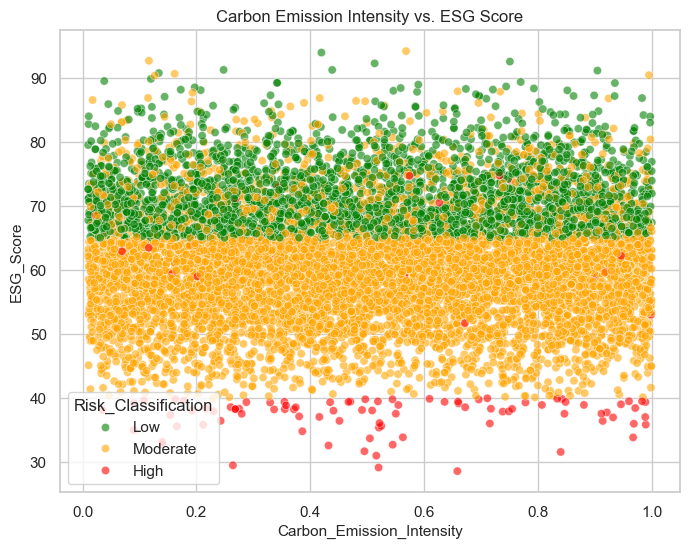

C:\Users\amtan\AppData\Local\Temp\ipykernel_25188\657337349.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=raw_df, x="Risk_Classification", y="ESG_Score", palette=risk_category_colours)


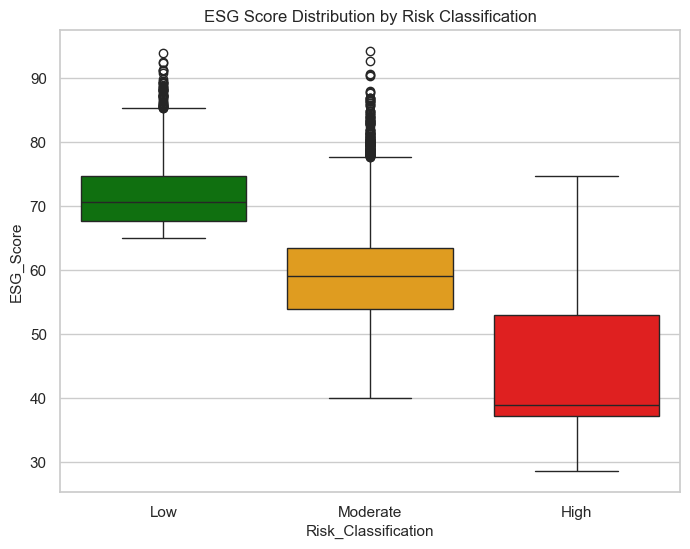

C:\Users\amtan\AppData\Local\Temp\ipykernel_25188\657337349.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=raw_df, x="Supplier_Tier", y="On_Time_Delivery_Rate", palette='Set2')


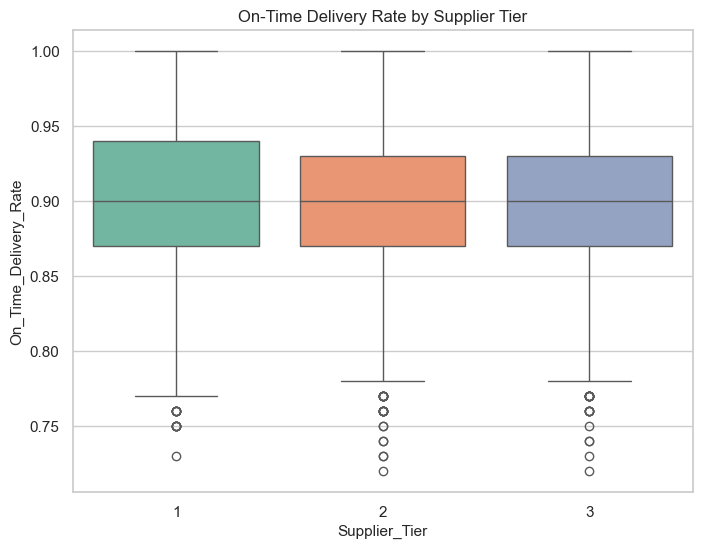

In [11]:
# Relationship analyses
plt.figure(figsize=(8, 6))
risk_category_colours = {'High' : 'Red', 'Moderate' : 'Orange', 'Low' : 'Green'}
sns.scatterplot(
    data=raw_df,
    x="Carbon_Emission_Intensity",
    y="ESG_Score",
    hue="Risk_Classification",
    palette=risk_category_colours,
    alpha=0.6,
)
plt.title("Carbon Emission Intensity vs. ESG Score")
plt.show()

# ESG Score Distribution by Risk Classification
plt.figure(figsize=(8, 6))
sns.boxplot(data=raw_df, x="Risk_Classification", y="ESG_Score", palette=risk_category_colours)
plt.title("ESG Score Distribution by Risk Classification")
plt.show()

# On-Time Delivery Rate by Supplier Tier
plt.figure(figsize=(8, 6))
sns.boxplot(data=raw_df, x="Supplier_Tier", y="On_Time_Delivery_Rate", palette='Set2')
plt.title("On-Time Delivery Rate by Supplier Tier")
plt.show()



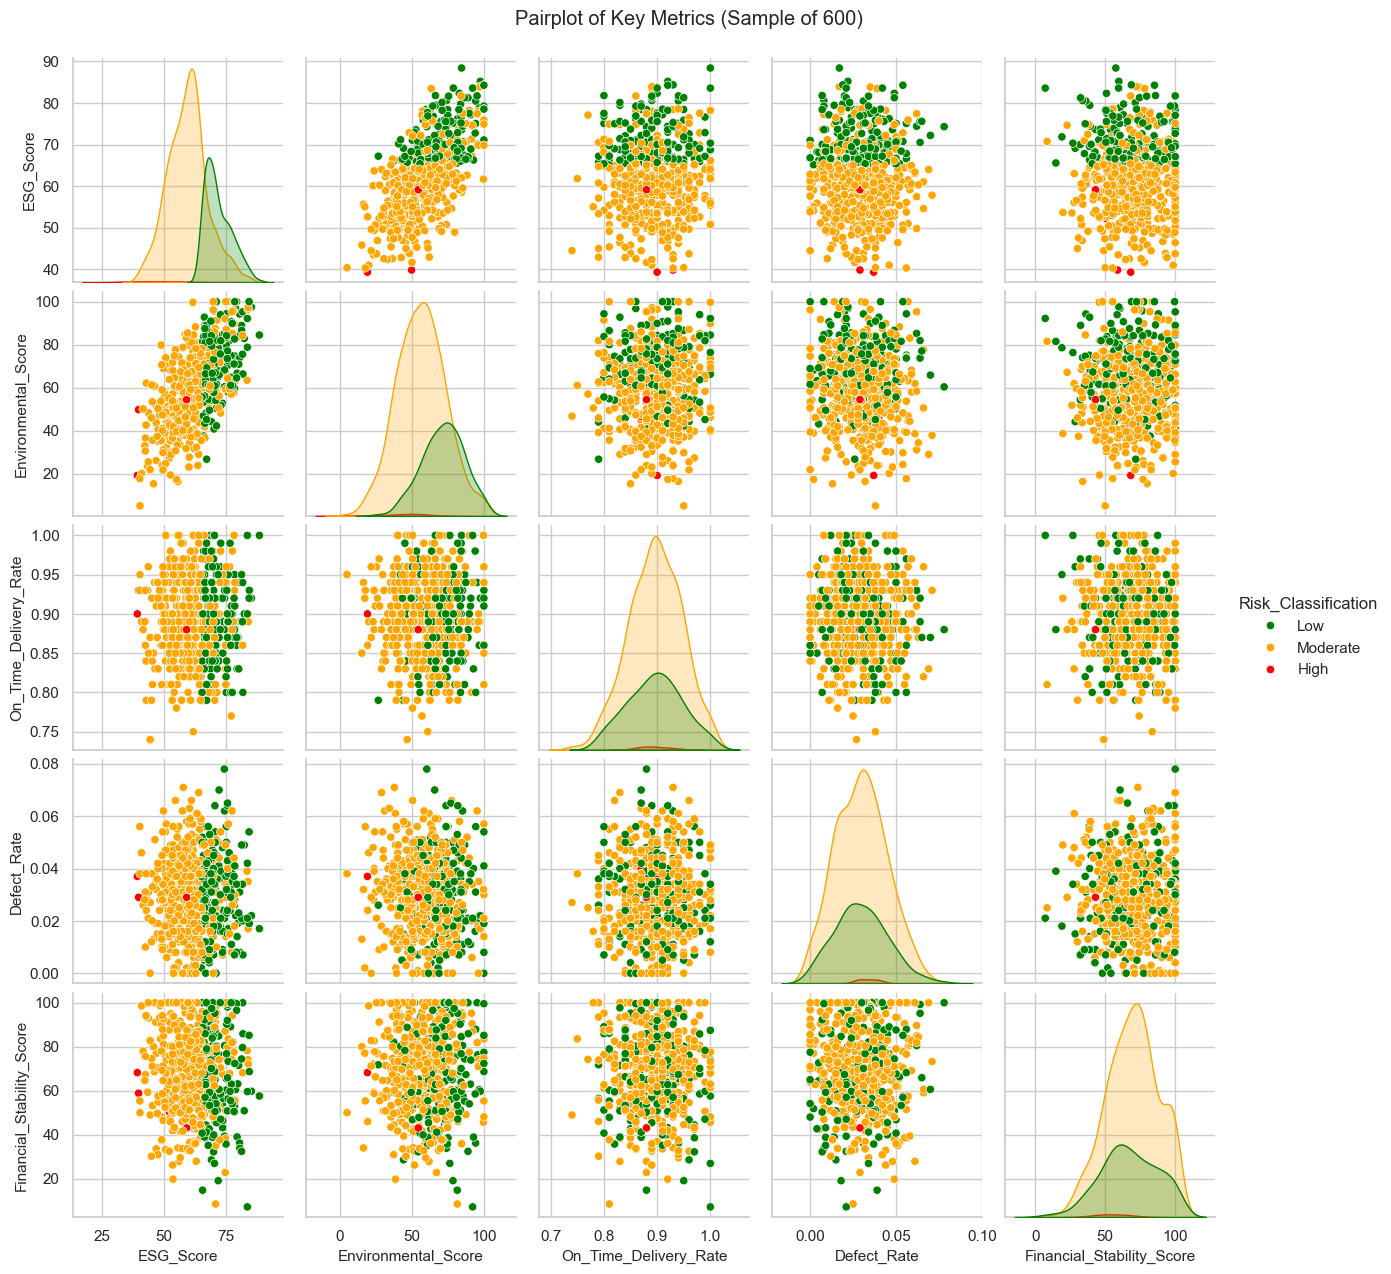

In [12]:
# Pairplot on a sample to inspect multivariate relationships
pairplot_cols = [
    "ESG_Score",
    "Environmental_Score",
    "On_Time_Delivery_Rate",
    "Defect_Rate",
    "Financial_Stability_Score",
    "Risk_Classification",
]
pairplot_sample = raw_df[pairplot_cols].dropna().sample(n=600, random_state=42)
sns.pairplot(pairplot_sample, hue="Risk_Classification", diag_kind="kde", palette=risk_category_colours)
plt.suptitle("Pairplot of Key Metrics (Sample of 600)", y=1.02)
plt.show()



In [13]:
# Compare raw vs processed dataset (sanity check)
comparison_metrics = [
    "ESG_Score",
    "Environmental_Score",
    "On_Time_Delivery_Rate",
    "Defect_Rate",
    "Logistics_Distance_km",
]
comparison = pd.DataFrame({
    "Raw Mean": raw_df[comparison_metrics].mean(),
    "Processed Mean": processed_df[comparison_metrics].mean(),
    "Raw Std": raw_df[comparison_metrics].std(),
    "Processed Std": processed_df[comparison_metrics].std(),
})
comparison


,Raw Mean,Processed Mean,Raw Std,Processed Std
ESG_Score,62.56,62.56,9.42,9.27
Environmental_Score,59.98,60.01,17.71,17.46
On_Time_Delivery_Rate,0.90,0.90,0.05,0.05
Defect_Rate,0.03,0.03,0.01,0.01
Logistics_Distance_km,6043.75,6044.21,3485.38,3450.52


### Key Takeaways
- Dataset covers 10,200 supplier-commodity records, heavily concentrated in Asia-Pacific and Agriculture/Electronics sectors.
- Sustainability sub-scores are moderately correlated, while higher carbon intensity trends toward higher risk classifications.
- Operational KPIs (on-time delivery, defect rate) vary by supplier tier; Tier 1 suppliers achieve tighter delivery performance.
- Missingness is limited (~2%) and primarily affects ESG sub-components, which the preprocessing pipeline now imputes and constrains.
- Processed data keeps central tendencies stable while reducing variance through winsorization and imputation, yielding a clean analytical baseline.



### Preprocessed Synthetic Supplier and Commodity Data

In [14]:
# Processed dataset summary
processed_numeric = processed_df.select_dtypes(include=np.number)
print(f"Total missing values in processed data: {processed_df.isna().sum().sum()}")
processed_summary = processed_numeric.describe().T
processed_summary[['mean', 'std', 'min', '25%', '50%', '75%', 'max']].round(2)


Total missing values in processed data: 0


,mean,std,min,25%,50%,75%,max
Supplier_Tier,2.01,0.82,1.00,1.00,2.00,3.00,3.00
ESG_Score,62.56,9.27,37.36,56.25,62.58,68.84,87.72
Environmental_Score,60.01,17.46,13.08,48.27,60.10,71.73,100.00
Social_Score,64.88,14.68,25.12,54.98,64.79,74.88,100.00
Governance_Score,62.91,15.70,20.02,52.24,63.10,73.72,100.00
Carbon_Emission_Intensity,0.51,0.28,0.01,0.26,0.51,0.75,1.00
Water_Intensity,776.67,413.04,50.19,424.80,780.21,1127.45,1499.50
Waste_Management_Efficiency,0.60,0.15,0.20,0.50,0.60,0.70,1.00
Renewable_Energy_Usage,0.40,0.19,0.00,0.27,0.40,0.53,0.92
Compliance_Level,1.53,1.12,0.00,1.00,2.00,3.00,3.00


In [15]:
# Risk classification aggregates on processed data
risk_metrics = [
    "ESG_Score",
    "Environmental_Score",
    "Carbon_Emission_Intensity",
    "On_Time_Delivery_Rate",
    "Defect_Rate",
    "Incident_History_Count",
]
risk_summary = processed_df.groupby("Risk_Classification")[risk_metrics].agg(["mean", "std"])
risk_summary.round(3)


ESG_Score       Environmental_Score        \
                         mean   std                mean   std   
Risk_Classification                                             
High                    46.03 12.07               41.56 17.78   
Low                     71.45  5.18               70.66 14.84   
Moderate                59.14  7.74               55.89 16.42   

                    Carbon_Emission_Intensity      On_Time_Delivery_Rate       \
                                         mean  std                  mean  std   
Risk_Classification                                                             
High                                     0.52 0.29                  0.91 0.05   
Low                                      0.51 0.28                  0.90 0.05   
Moderate                                 0.51 0.28                  0.90 0.05   

                    Defect_Rate      Incident_History_Count       
                           mean  std                   mean  std  
Risk_Classification                                               
High                       0.03 0.01                   2.14 2.04  
Low                        0.03 0.01                   0.50 0.50  
Moderate                   0.03 0.01                   1.20 1.03

C:\Users\amtan\AppData\Local\Temp\ipykernel_25188\2154720172.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=processed_df, x="Risk_Classification", y="ESG_Score", ax=axes[0], palette="Set2")
C:\Users\amtan\AppData\Local\Temp\ipykernel_25188\2154720172.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=processed_df, x="Risk_Classification", y="Carbon_Emission_Intensity", ax=axes[1], palette="Set3")
C:\Users\amtan\AppData\Local\Temp\ipykernel_25188\2154720172.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=processed

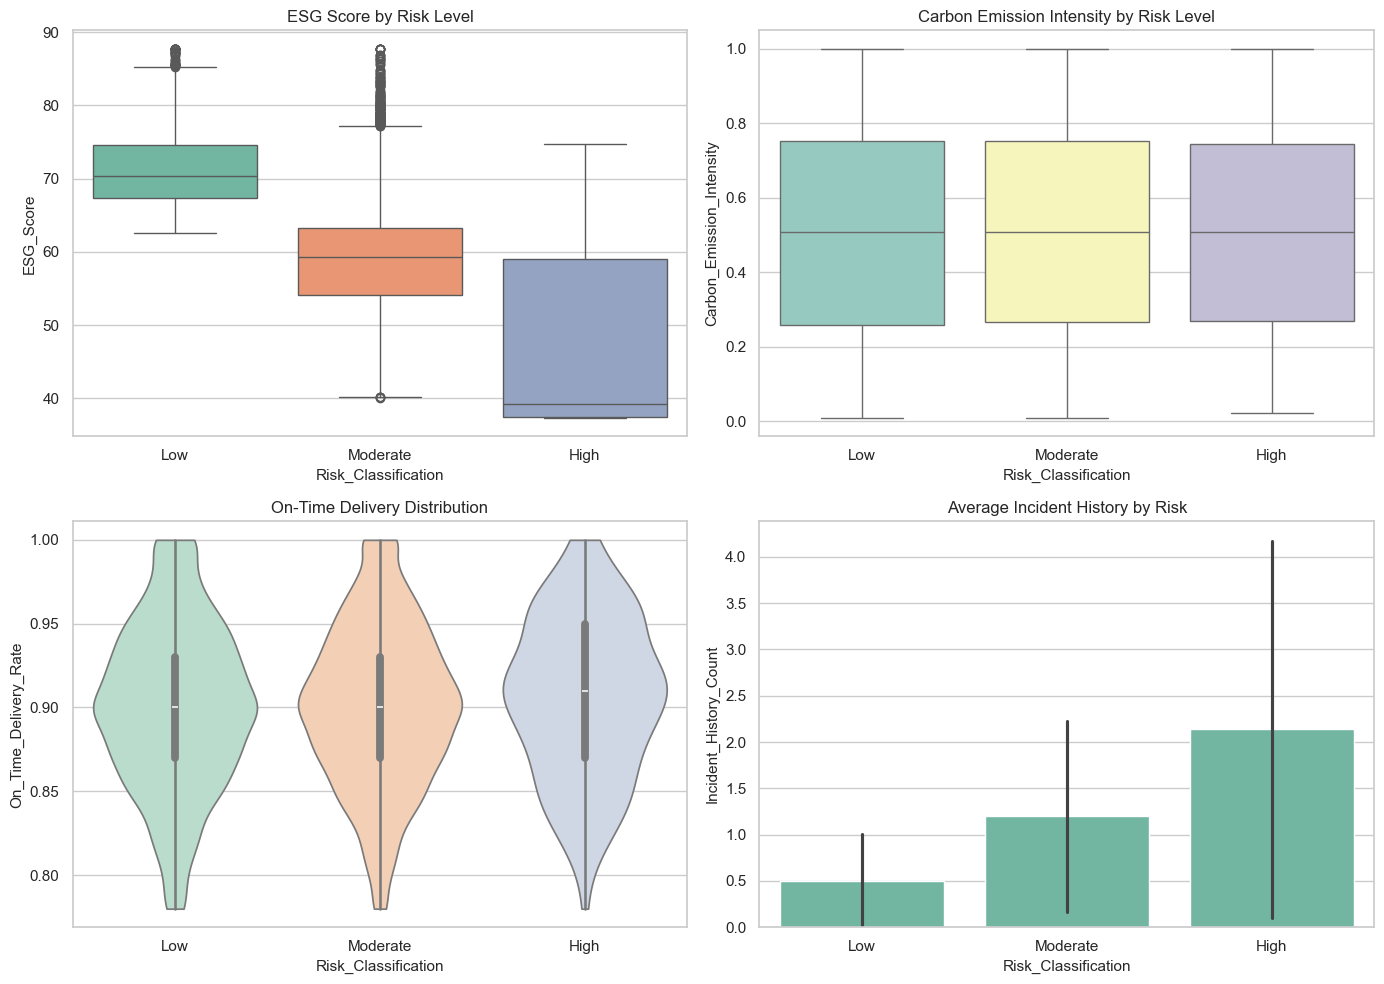

In [ ]:
# Processed data visualizations by risk level
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

sns.boxplot(data=processed_df, x="Risk_Classification", y="ESG_Score", ax=axes[0], palette="Set2")
axes[0].set_title("ESG Score by Risk Level")

sns.boxplot(data=processed_df, x="Risk_Classification", y="Carbon_Emission_Intensity", ax=axes[1], palette="Set3")
axes[1].set_title("Carbon Emission Intensity by Risk Level")

sns.violinplot(data=processed_df, x="Risk_Classification", y="On_Time_Delivery_Rate", ax=axes[2], palette="Pastel2", cut=0)
axes[2].set_title("On-Time Delivery Distribution")

sns.barplot(
    data=processed_df,
    x="Risk_Classification",
    y="Incident_History_Count",
    estimator=np.mean,
    errorbar='sd',
    ax=axes[3],
)
axes[3].set_title("Average Incident History by Risk")
plt.tight_layout()
plt.show()

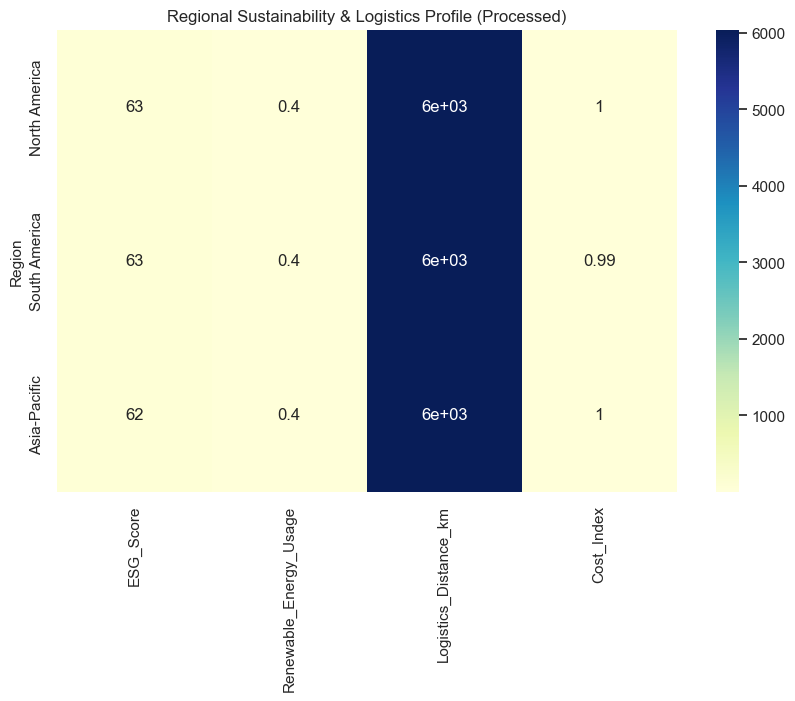

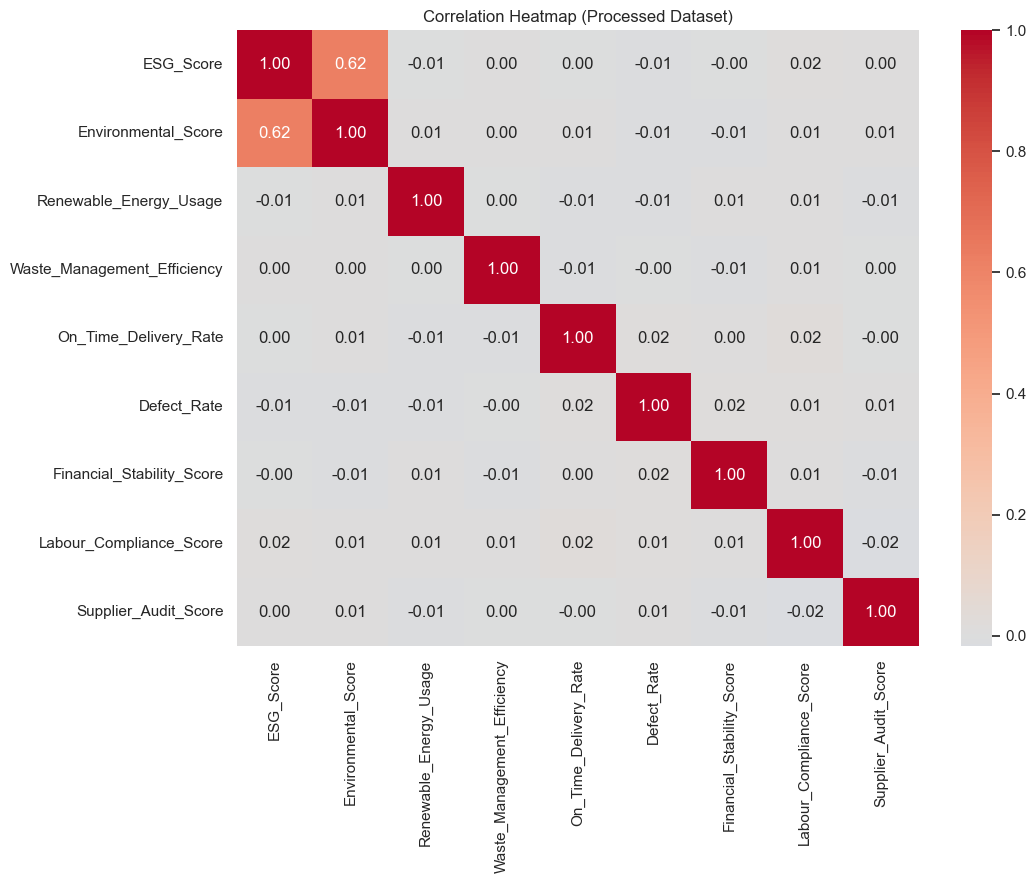

In [17]:
# Regional sustainability footprint on processed data
regional_metrics = processed_df.groupby("Region")[
    ["ESG_Score", "Renewable_Energy_Usage", "Logistics_Distance_km", "Cost_Index"]
].mean().sort_values("ESG_Score", ascending=False)
regional_metrics.round(2)

plt.figure(figsize=(10, 6))
sns.heatmap(regional_metrics.round(2), annot=True, cmap="YlGnBu")
plt.title("Regional Sustainability & Logistics Profile (Processed)")
plt.show()

processed_corr = processed_df[
    [
        "ESG_Score",
        "Environmental_Score",
        "Renewable_Energy_Usage",
        "Waste_Management_Efficiency",
        "On_Time_Delivery_Rate",
        "Defect_Rate",
        "Financial_Stability_Score",
        "Labour_Compliance_Score",
        "Supplier_Audit_Score",
    ]
].corr()
plt.figure(figsize=(11, 8))
sns.heatmap(processed_corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation Heatmap (Processed Dataset)")
plt.show()
